# Configuration

In [1]:
import os 
import pickle 

if True ^ os.getcwd().endswith('hte-and-targeting"'):
    os.chdir('..')


In [2]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [3]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

# model label map 
model_label_map = {
    'plugin': 'Plugin', 
    'standard_bootstrap': 'Standard Bootstrap', 
    'mn_bootstrap': 'm-out-of-n Bootstrap', 
    'num_bootstrap': 'Numerical Bootstrap'
}

In [6]:
from scipy.stats import truncnorm, norm
from scipy.optimize import fsolve

In [4]:
from core.variables import *
from core.dgp import SingleSegmentTreatmentSelection as SingleSegment
import core.treatment_selection_single_segment as ts

# Model

In [8]:
def andrews_et_al_2023(
    treatments: np.ndarray, outcomes: np.ndarray, quantile: float = 0.5
) -> tuple:
    # estimate targeting policy
    emp_te_arr = ts.estimate_te(treatments=treatments, outcomes=outcomes)
    plugin_decision, _ = ts.optimize(te_arr=emp_te_arr)

    # 
    selected_std = np.std(outcomes[treatments == plugin_decision]) / np.sum(treatments == plugin_decision) ** 0.5
    selected_val = emp_te_arr[plugin_decision]
    remaining_max_val = np.max(np.delete(emp_te_arr, plugin_decision))

    def truncated_normal_cdf(x, mu) -> float:
        trunc_lb = (remaining_max_val - mu) / selected_std

        return truncnorm.cdf(x, trunc_lb, np.inf, loc=mu, scale=selected_std)
    
    return fsolve(
        func=lambda mu: truncated_normal_cdf(selected_val, mu) - (1-quantile), x0=0
    )[0]

In [16]:
dgp_params = {'te_arr': np.array([0.1, 0.15]), 'noise_std': 1}
dgp = SingleSegment(**dgp_params)
treatment_arr, outcome_arr = dgp.sample(100)

In [24]:
# estimate targeting policy
emp_te_arr = ts.estimate_te(treatments=treatment_arr, outcomes=outcome_arr)
plugin_decision, _ = ts.optimize(te_arr=emp_te_arr)

# calculate the related statistics
selected_std = np.std(outcome_arr[treatment_arr == plugin_decision]) / np.sum(treatment_arr == plugin_decision) ** 0.5
selected_val = emp_te_arr[plugin_decision]
remaining_max_val = np.max(np.delete(emp_te_arr, plugin_decision))

# calculate the quantile
quantile = 0.5
mu = andrews_et_al_2023(treatments=treatment_arr, outcomes=outcome_arr, quantile=quantile)

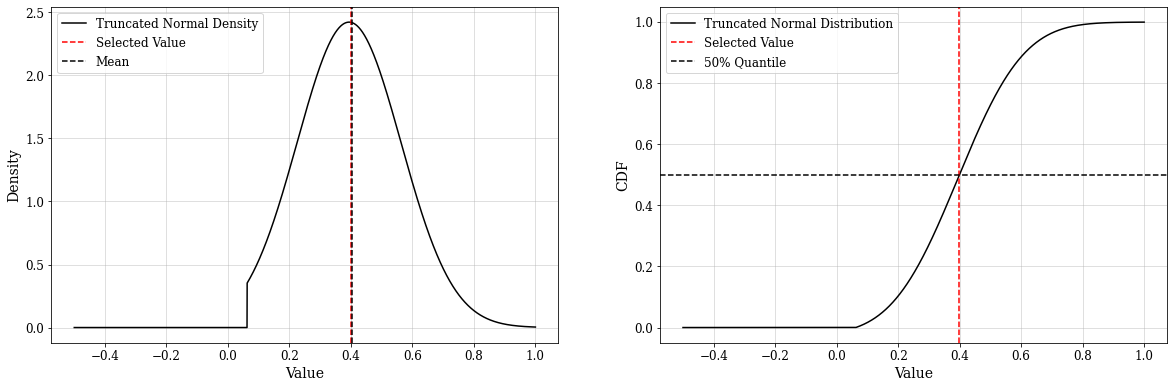

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6.18))

x = np.linspace(-0.5, 1.0, 10000)

# plot the pdf of truncated normal distribution
y = truncnorm.pdf(x, (remaining_max_val - mu) / selected_std, np.inf, loc=mu, scale=selected_std)
axes[0].plot(x, y, color='black', label='Truncated Normal Density')
axes[0].axvline(selected_val, color='red', linestyle='--', label='Selected Value')
axes[0].axvline(truncnorm.mean(a=(remaining_max_val - mu) / selected_std, b=np.inf, loc=mu, scale=selected_std), color='black', linestyle='--', label='Mean')
axes[0].set_ylabel('Density', fontsize=axis_label_size)

# plt the cdf of truncated normal distribution
y = truncnorm.cdf(x, (remaining_max_val - mu) / selected_std, np.inf, loc=mu, scale=selected_std)
axes[1].plot(x, y, color='black', label='Truncated Normal Distribution')
axes[1].axvline(selected_val, color='red', linestyle='--', label='Selected Value')
axes[1].axhline(0.5, color='black', linestyle='--', label='50% Quantile')
axes[1].set_ylabel('CDF', fontsize=axis_label_size)

for ax in axes:
    ax.grid(True, alpha=0.5)
    ax.set_xlabel('Value', fontsize=axis_label_size)
    ax.legend(fontsize=legend_label_size)
    ax.tick_params(axis='both', which='major', labelsize=tick_label_size)


plt.show()

In [38]:
n_repeats = 1000
result_records = [None] * n_repeats

for idx in range(n_repeats):
    treatment_arr, outcome_arr = dgp.sample(100)
    
    true_max = np.max(dgp_params['te_arr'])
    estimated_max = andrews_et_al_2023(treatments=treatment_arr, outcomes=outcome_arr, quantile=quantile)

    is_overestimate = estimated_max > true_max

    result_records[idx] = {
        'true_max': true_max,
        'estimated_max': estimated_max,
        'is_overestimate': is_overestimate
    }

/Users/iamsikun/miniforge3/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


In [39]:
result_df = pd.DataFrame.from_records(result_records)
result_df['winners_curse'] = result_df['estimated_max'] - result_df['true_max']

wc_avg = result_df['winners_curse'].mean()
wc_se = result_df['winners_curse'].std() / 100 ** 0.5
pct_overestimate = result_df['is_overestimate'].mean()

print(f'Average Winner\'s Curse: {wc_avg:.4f} ({wc_se:.4f})')
print(f'Percentage of Overestimates: {100 * pct_overestimate:.2f} %')

Average Winner's Curse: -0.7090 (1.3127)
Percentage of Overestimates: 45.70 %
